In [1]:
import os
import sys
import random
import optuna
import numpy as np
import pandas as pd
from dotenv import load_dotenv

sys.path.append("..")
from feature_engineering import time_based_train_test_split, get_return, round_to_step, get_mask, add_week_column, objective
from etl_pipeline_local import get_under_25_table

sys.path.append("../..")
from strategies.strategies_utils import analyze_strategies, get_best_strategies

from utils import trial_key, run_one_study
pd.set_option('display.max_columns', None)
optuna.logging.set_verbosity(optuna.logging.WARN)

load_dotenv()

True

In [2]:
import yaml
from datetime import datetime

START_DATE_STR = "17-08-2026"
start_date = datetime.strptime(START_DATE_STR, "%d-%m-%Y")

with open("../../config.yaml", "r") as f:
    config = yaml.safe_load(f)

leagues = config["leagues"]

# 1. Load Data

In [3]:
# Bet setup
target_col = "under_25"
odds_col: str = "underOver_quote_currentU"

# Load data
df_loaded = get_under_25_table()
df_loaded = df_loaded.sort_values('time').reset_index(drop=True)
df = df_loaded.copy()

# Feature Engineering
df["return"] = df.apply(lambda x: get_return(strategy=x[target_col], odds=x[odds_col]), axis=1).copy()
df["week"] = add_week_column(df)
df = df[(df[target_col] >= 1.3) | (df[target_col] <= 2.5)]

feature_bins_map = {
'chance1x2_xg_home': 0.1, 
'chance1x2_xg_away': 0.1, 
# 'chance1x2_xg_total': 0.1,
 }

df = df.dropna(subset=feature_bins_map.keys())

# Drop unused features
cols = ['time', 'team_league', target_col, 'return', 'week'] + list(feature_bins_map.keys())
to_drop =  [x for x in df.columns if x not in cols]
df = df.drop(to_drop, axis=1)

# Filters
df = df[df['time'] >= start_date]
df = df[df['team_league'].isin(leagues)]
###


# # Train/test split
df_train, df_test = time_based_train_test_split(df=df, time_col="time", train_frac=0.8)

## 2. Define Parameters

In [4]:
# Define features and relative step

objective_hyperparameters = {
    "n_trials": 500, # 500 - 1000
    "n_studies": 20, # 50
    "min_obs": 100, 
    "lambda": 1, # 0.5, 1, 2
    "tpe_sampler": 
    {
        "n_startup_trials": 100, # 10 - 30 per search space semplici, 50 100+ per seearch space con molti minimi
        "n_ei_candidates": 128 # 24 default, problemi difficili: 64 o 128
    }
}

# Create the binned dataframe
df_train_binned = df_train.dropna(subset=feature_bins_map.keys()).copy()

for feat, step in feature_bins_map.items():
    df_train_binned[feat] = [round_to_step(x, step) for x in df_train_binned[feat]]

    if isinstance(step, int):
        df_train_binned[feat] = df_train_binned[feat].astype("Int64")

print("SEARCH SPACE\n")
for feat in feature_bins_map.keys():
    space = df_train_binned[feat].sort_values(ascending=True).unique()
    print(f"Feature: {feat}")
    print(f"Search space: {space}")
    print("\n")

SEARCH SPACE

Feature: chance1x2_xg_home
Search space: [0.4 0.7 0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7 1.8 1.9 2.  2.1 2.2 2.3
 2.4 2.5 2.6 2.7 2.8 3. ]


Feature: chance1x2_xg_away
Search space: [0.6 0.7 0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7 1.8 1.9 2.  2.1 2.2 2.3
 2.4 2.5 2.6 2.7 2.8 3.1]




## 3. Optimize

In [5]:
optuna.logging.set_verbosity(optuna.logging.WARN)

# Generate random seeds
seeds = [random.randint(0, 2**32 - 1) for _ in range(objective_hyperparameters["n_studies"])]
studies = [
    run_one_study(
        seed=s, 
        objective_hyperparameters=objective_hyperparameters, 
        objective=objective,
        feature_bins_map=feature_bins_map, 
        df_binned=df_train_binned
        ) 
        for s in seeds]

all_trials = []
for study in studies:
    all_trials.extend(
        [t for t in study.trials if t.value is not None and t.state.name == "COMPLETE"]
    )

top_trials = sorted(all_trials, key=lambda t: -t.value)
best_trials = top_trials[:10]
print(best_trials)

/home/maicolnicolini/code/bet-master-analytics/src/models/under_25/../feature_engineering.py:322: UserWarning: The distribution is specified by [0.6000000000000001, 3.0] and step=0.1, but the range is not divisible by `step`. It will be replaced with [0.6000000000000001, 2.9].
  feat_min = trial.suggest_float(
/home/maicolnicolini/code/bet-master-analytics/src/models/under_25/../feature_engineering.py:328: UserWarning: The distribution is specified by [0.6000000000000001, 3.1] and step=0.1, but the range is not divisible by `step`. It will be replaced with [0.6000000000000001, 3.0].
  feat_max = trial.suggest_float(
/home/maicolnicolini/code/bet-master-analytics/src/models/under_25/../feature_engineering.py:322: UserWarning: The distribution is specified by [0.6000000000000001, 3.0] and step=0.1, but the range is not divisible by `step`. It will be replaced with [0.6000000000000001, 2.9].
  feat_min = trial.suggest_float(
/home/maicolnicolini/code/bet-master-analytics/src/models/under_

[FrozenTrial(number=370, state=<TrialState.COMPLETE: 1>, values=[1.331563237049577], datetime_start=datetime.datetime(2026, 9, 22, 16, 7, 2, 834994), datetime_complete=datetime.datetime(2026, 9, 22, 16, 7, 2, 860551), params={'chance1x2_xg_home_use_min': True, 'chance1x2_xg_home_use_max': True, 'use_chance1x2_xg_home': True, 'chance1x2_xg_home_min': 1.2000000000000002, 'chance1x2_xg_home_max': 1.6, 'chance1x2_xg_away_use_min': False, 'chance1x2_xg_away_use_max': True, 'use_chance1x2_xg_away': False, 'chance1x2_xg_away_min': 2.0, 'chance1x2_xg_away_max': 2.1}, user_attrs={'params_dict': {'chance1x2_xg_home_use_min': True, 'chance1x2_xg_home_use_max': True, 'use_chance1x2_xg_home': True, 'chance1x2_xg_home_min': 1.2000000000000002, 'chance1x2_xg_home_max': 1.6, 'chance1x2_xg_away_use_min': False, 'chance1x2_xg_away_use_max': True, 'use_chance1x2_xg_away': False, 'chance1x2_xg_away_min': 2.0, 'chance1x2_xg_away_max': 2.1}}, system_attrs={}, intermediate_values={}, distributions={'chance1x

## 4. Evaluate

In [6]:
# Create the test binned dataframe
return_threshold = -5.
df_test_binned = df_test.copy()

for feat, step in feature_bins_map.items():
    df_test_binned[feat] = [round_to_step(x, step) for x in df_test_binned[feat]]

    if isinstance(step, int):
        df_test_binned[feat] = df_test_binned[feat].astype("Int64")

# Get the resulting dataframes
for i, trial in enumerate(best_trials):
    params_dict = best_trials[i].user_attrs["params_dict"]

    train_mask = get_mask(df_train_binned, params_dict)
    test_mask = get_mask(df_test_binned, params_dict)

    df_train_filtered = df_train_binned[train_mask]
    df_test_filtered = df_test_binned[test_mask]

    df = pd.concat([df_train_filtered, df_test_filtered], axis=0)
    min_return = df.groupby('week')['return'].sum().min()
    max_return = df.groupby('week')['return'].sum().max()

    if min_return >= return_threshold:
        print(f"Trial no. {i}")
        print(f"Min return {min_return}")
        print(f"Max return {max_return}")
        print(f"Score {trial.value}")
        print("\n")

Trial no. 0
Min return -1.9
Max return 8.440000000000001
Score 1.331563237049577


Trial no. 1
Min return -1.9
Max return 8.440000000000001
Score 1.331563237049577


Trial no. 2
Min return -1.9
Max return 8.440000000000001
Score 1.331563237049577


Trial no. 3
Min return -1.9
Max return 8.440000000000001
Score 1.331563237049577


Trial no. 4
Min return -1.9
Max return 8.440000000000001
Score 1.331563237049577


Trial no. 5
Min return -1.9
Max return 8.440000000000001
Score 1.331563237049577


Trial no. 6
Min return -1.9
Max return 8.440000000000001
Score 1.331563237049577


Trial no. 7
Min return -1.9
Max return 8.440000000000001
Score 1.331563237049577


Trial no. 8
Min return -1.9
Max return 8.440000000000001
Score 1.331563237049577


Trial no. 9
Min return -1.9
Max return 8.440000000000001
Score 1.331563237049577




Mean Train ROI: 0.09466666666666668
Train Accuracy: 0.5 (106/210)
Mean Test ROI: -0.02
Test Accuracy: 0.5 (25/53)


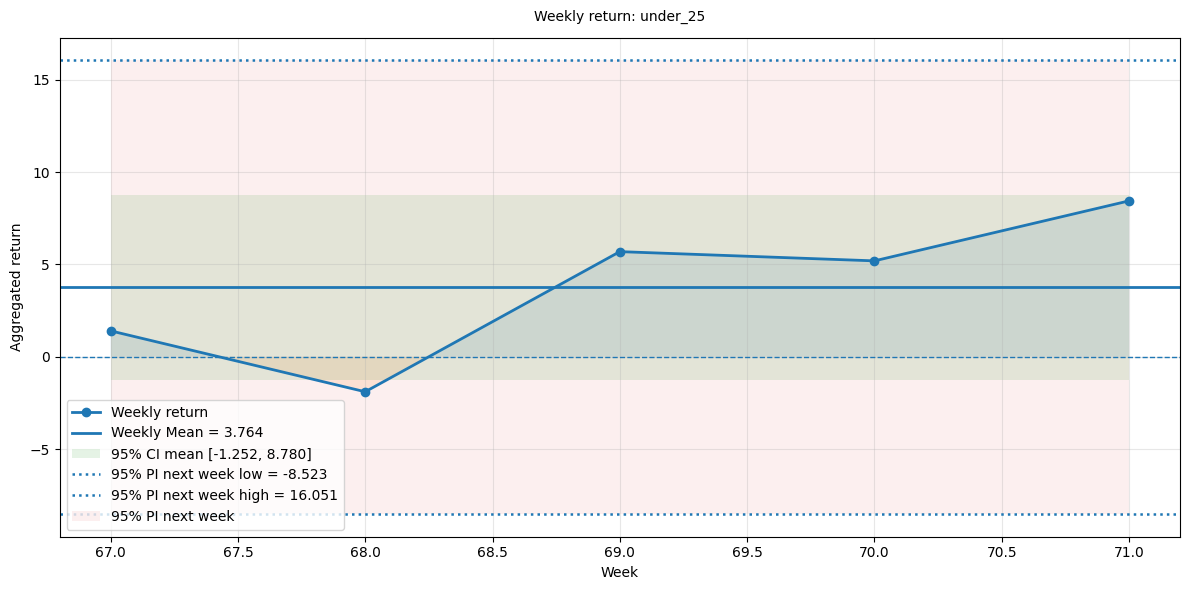

In [7]:
best_score_idx = 0

params_dict = best_trials[best_score_idx].user_attrs["params_dict"]

train_mask = get_mask(df_train_binned, params_dict)
test_mask = get_mask(df_test_binned, params_dict)

df_train_filtered = df_train_binned[train_mask]
df_test_filtered = df_test_binned[test_mask]


mean_roi = df_train_filtered["return"].mean()
right = df_train_filtered[target_col].sum()  
total = df_train_filtered.shape[0]

accuracy = np.round((right / total), 1)
print(f"Mean Train ROI: {mean_roi}")
print(f"Train Accuracy: {accuracy} ({right}/{total})")


mean_roi = df_test_filtered["return"].mean()
right = df_test_filtered[target_col].sum()  
total = df_test_filtered.shape[0]

accuracy = np.round((right / total), 1)
print(f"Mean Test ROI: {mean_roi}")
print(f"Test Accuracy: {accuracy} ({right}/{total})")


df_tot_filtered = pd.concat([df_train_filtered, df_test_filtered], axis=0).reset_index(drop=True).rename(columns={target_col: "result", "time": "date"})
df_tot_filtered = df_tot_filtered.sort_values(by="date", ascending=False)
 
df_tot_filtered["strategy"] = target_col

weekly_return, stats = analyze_strategies(df_tot_filtered, strategies=[target_col], print_pi=True)

In [8]:
# Get Stats
weeks = stats["n_weeks"]
total_weeks = max(df["week"])

print(f"No. of weeks covered: {weeks}/{total_weeks} ({np.round((weeks/total_weeks), 2)})")
weekly_stats = get_best_strategies(df_tot_filtered).iloc[0].to_dict()
weekly_stats["weeks_covered"] = np.round((weeks/total_weeks), 2)

get_best_strategies(df_tot_filtered)

No. of weeks covered: 5/71 (0.07)


,weekly_mean_return,weekly_std_return,weekly_counts,weekly_std_counts,total_counts,accuracy
under_25,3.76,4.04,3.70,16.70,263,0.49


## 5. Save best Trials

In [9]:
# Save best trials 
trial_to_save = best_trials[best_score_idx]

trial_to_save.set_user_attr("feature_bins_map", feature_bins_map)
trial_to_save.set_user_attr("weekly_stats", weekly_stats) 

study = optuna.create_study(
    study_name=f"{target_col}_aggregated_study",
    storage=os.getenv("OPTUNA_STORAGE"),
    direction="maximize",   
    load_if_exists=True,
)

existing = {trial_key(t) for t in study.trials if t.value is not None}

# esempio: best_frozen_trials = [study_seed_1.best_trial, study_seed_2.best_trial, ...]
new_best_trials = [
    t for t in [trial_to_save]
    if trial_key(t) not in existing
]

if new_best_trials:
    study.add_trials(new_best_trials)

print("Aggiunti:", len(new_best_trials))
print("Totale trial archiviati:", len(study.trials))
print("Best assoluto:", study.best_trial.value, study.best_trial.params)

Aggiunti: 1
Totale trial archiviati: 1
Best assoluto: 1.331563237049577 {'chance1x2_xg_home_use_min': True, 'chance1x2_xg_home_use_max': True, 'use_chance1x2_xg_home': True, 'chance1x2_xg_home_min': 1.2000000000000002, 'chance1x2_xg_home_max': 1.6, 'chance1x2_xg_away_use_min': False, 'chance1x2_xg_away_use_max': True, 'use_chance1x2_xg_away': False, 'chance1x2_xg_away_min': 2.0, 'chance1x2_xg_away_max': 2.1}


/tmp/ipykernel_98839/4034433927.py:26: UserWarning: The distribution is specified by [0.6000000000000001, 2.9] and step=0.1, but the range is not divisible by `step`. It will be replaced with [0.6000000000000001, 2.8000000000000003].
  print("Totale trial archiviati:", len(study.trials))
/tmp/ipykernel_98839/4034433927.py:26: UserWarning: The distribution is specified by [0.6000000000000001, 3.0] and step=0.1, but the range is not divisible by `step`. It will be replaced with [0.6000000000000001, 2.9].
  print("Totale trial archiviati:", len(study.trials))
